# S4003 / S4009 — Synthèse unifiée : EWC INT8 sur MCU

**Une seule source de vérité.** Depuis la refonte S4009, ce notebook ne trace plus les figures
lui-même : il appelle le catalogue `article_ewc_int8` (`src/figures/catalogs/article_ewc.py`), qui
lit l'agrégat `experiments/exp_S40_article_metrics/summary.json` produit par
`scripts/aggregate_article_ewc.py`. Le notebook reste responsable de la **table de provenance**
consommée par l'article et les tests.

Deux règles du dépôt s'appliquent partout ici :

* **aucun chiffre inventé** — une cellule non mesurée vaut `None` ou le sentinel `« à mesurer »`,
  jamais 0 ;
* **les trois estimateurs d'énergie ne sont jamais fusionnés** — leur désaccord est un résultat.


In [1]:
import json, sys
from pathlib import Path

from IPython.display import Image, display

# ── Racine du dépôt (remonte jusqu'à experiments/) ──
ROOT = Path.cwd()
while not (ROOT / "experiments").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import src.figures.catalogs  # noqa: F401 — auto-enregistrement des catalogues
from src.figures import registry
from src.figures.style import DEFAULT_OUT_ROOT, apply_style
from src.utils.reproducibility import set_seed

EXP = ROOT / "experiments"
FIGS = ROOT / "docs" / "figures" / "sprint40_article"
FIGS.mkdir(parents=True, exist_ok=True)
NA = "à mesurer"                      # règle « aucun chiffre inventé »
DATASETS = ["pronostia", "monitoring"]

SUMMARY = json.loads((EXP / "exp_S40_article_metrics" / "summary.json").read_text(encoding="utf-8"))
print("Agrégat chargé :", SUMMARY["_meta"]["generated_at"])
print("Cellules non mesurées :", len(SUMMARY["missing"]))

Agrégat chargé : 2026-09-08T22:47:33
Cellules non mesurées : 28


## 1. Régénération des figures (déléguée au catalogue)

Le catalogue produit les 10 PNG sous `docs/figures/article_ewc_int8/` puis les **synchronise** vers
`docs/article/ewc_int8_mcu/figures/` et `docs/figures/sprint40_article/`. C'est cette copie
automatique qui supprime la dérive constatée avant la refonte (`fig2`, `fig4` et `fig5` avaient
divergé entre les deux répertoires).

In [2]:
set_seed(42)
apply_style("manuscript")
paths = registry.get_catalog("article_ewc_int8")(DEFAULT_OUT_ROOT)
FIG_NAMES = [p.name for p in paths]
FIG_NAMES

✅ Seed fixé à 42
[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/article_ewc_int8/fig1_parity_fp32_pc_board.png


[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/article_ewc_int8/fig2_latency_gap2.png
[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/article_ewc_int8/fig3_ablation_ladder.png


[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/article_ewc_int8/fig4_int8_recovery_board.png
[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/article_ewc_int8/fig5_pareto_ram_f1_latency.png


[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/article_ewc_int8/fig6_quant_moment.png
[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/article_ewc_int8/fig7_quant_depth_packing.png


[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/article_ewc_int8/fig8_ram_total.png
[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/article_ewc_int8/fig9_energy_estimators.png


[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/article_ewc_int8/fig10_compute_cost.png
[figures] synchronisé vers 2 répertoire(s) : docs/article/ewc_int8_mcu/figures, docs/figures/sprint40_article


['fig1_parity_fp32_pc_board.png',
 'fig2_latency_gap2.png',
 'fig3_ablation_ladder.png',
 'fig4_int8_recovery_board.png',
 'fig5_pareto_ram_f1_latency.png',
 'fig6_quant_moment.png',
 'fig7_quant_depth_packing.png',
 'fig8_ram_total.png',
 'fig9_energy_estimators.png',
 'fig10_compute_cost.png']

## 2. Les figures

Convention de lecture maintenue dans toutes les figures : **plein = mesuré carte**,
**hachuré = émulé PC ou théorique**, **gris = non mesuré**.

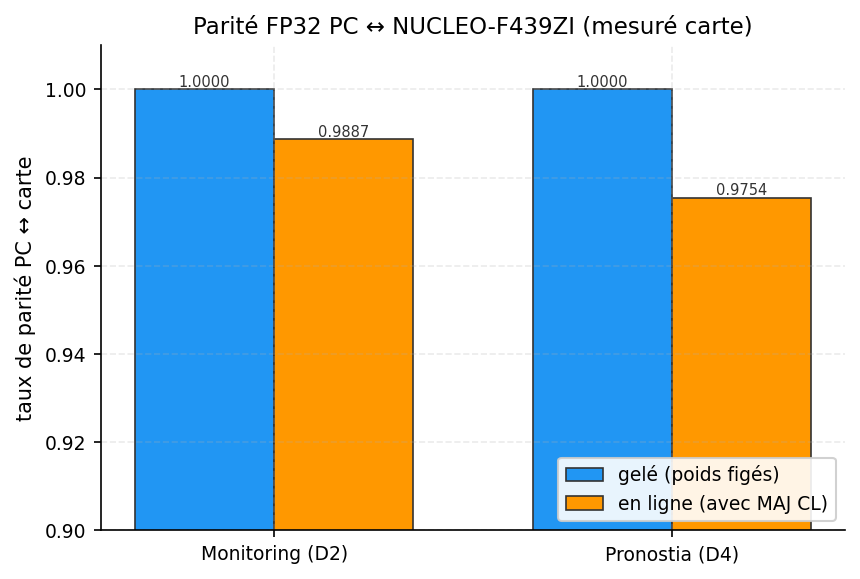

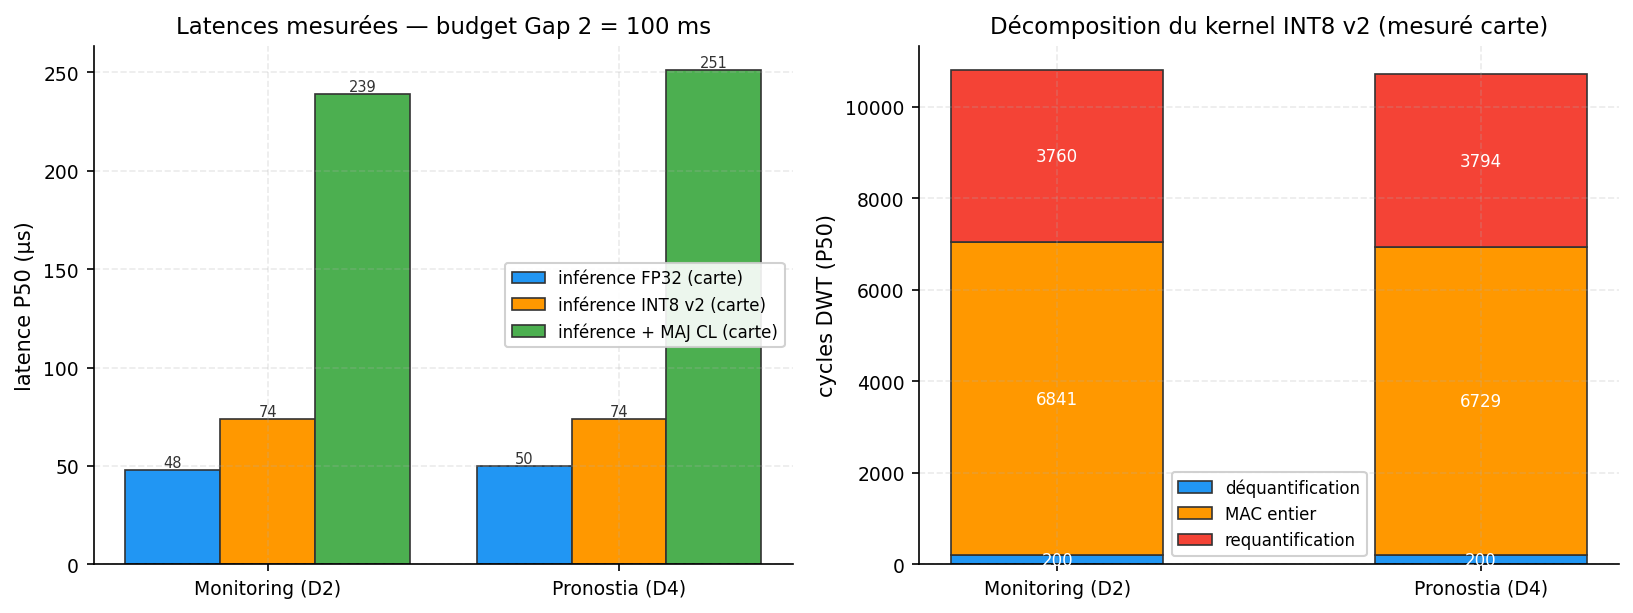

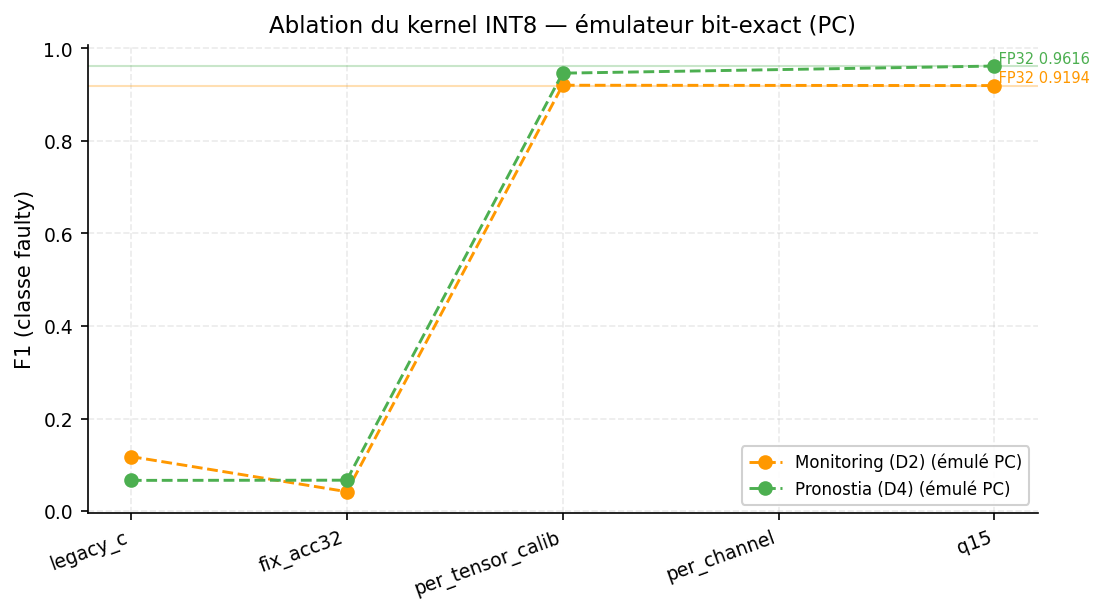

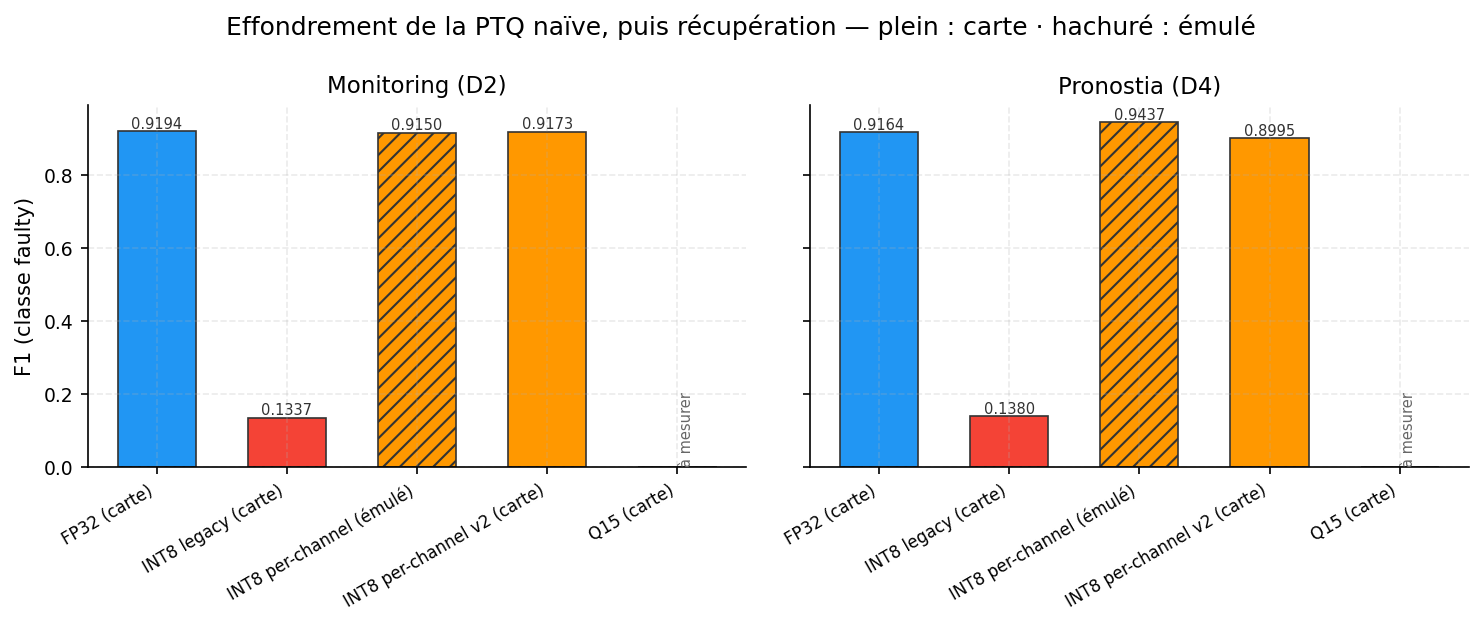

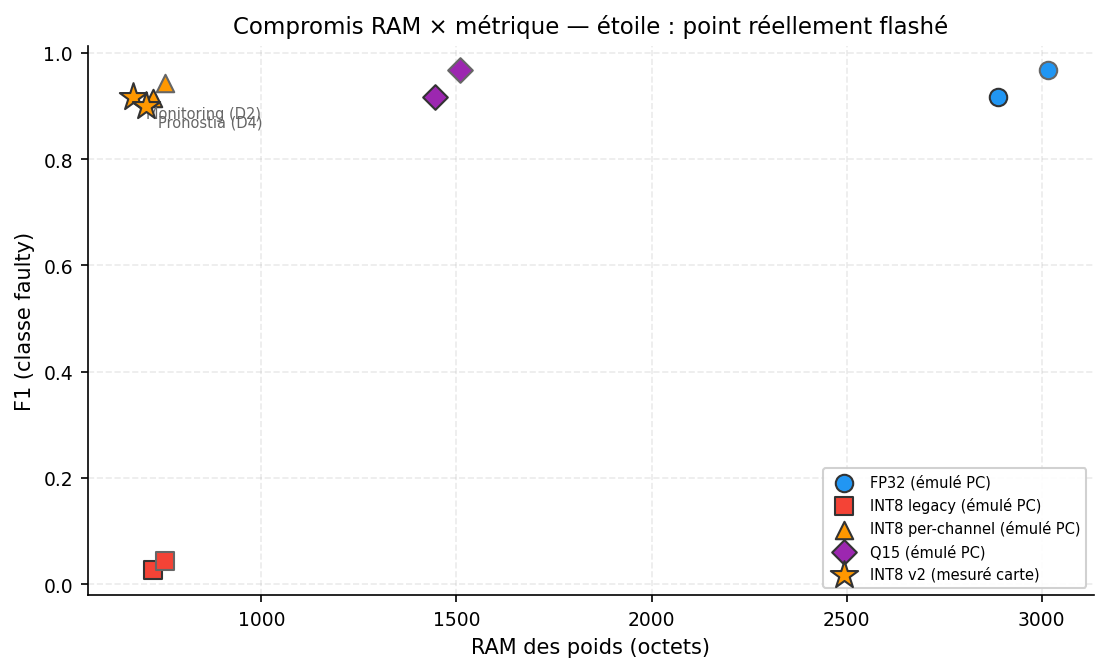

In [3]:
for name in [
    "fig1_parity_fp32_pc_board.png",
    "fig2_latency_gap2.png",
    "fig3_ablation_ladder.png",
    "fig4_int8_recovery_board.png",
    "fig5_pareto_ram_f1_latency.png",
]:
    display(Image(filename=str(FIGS / name)))

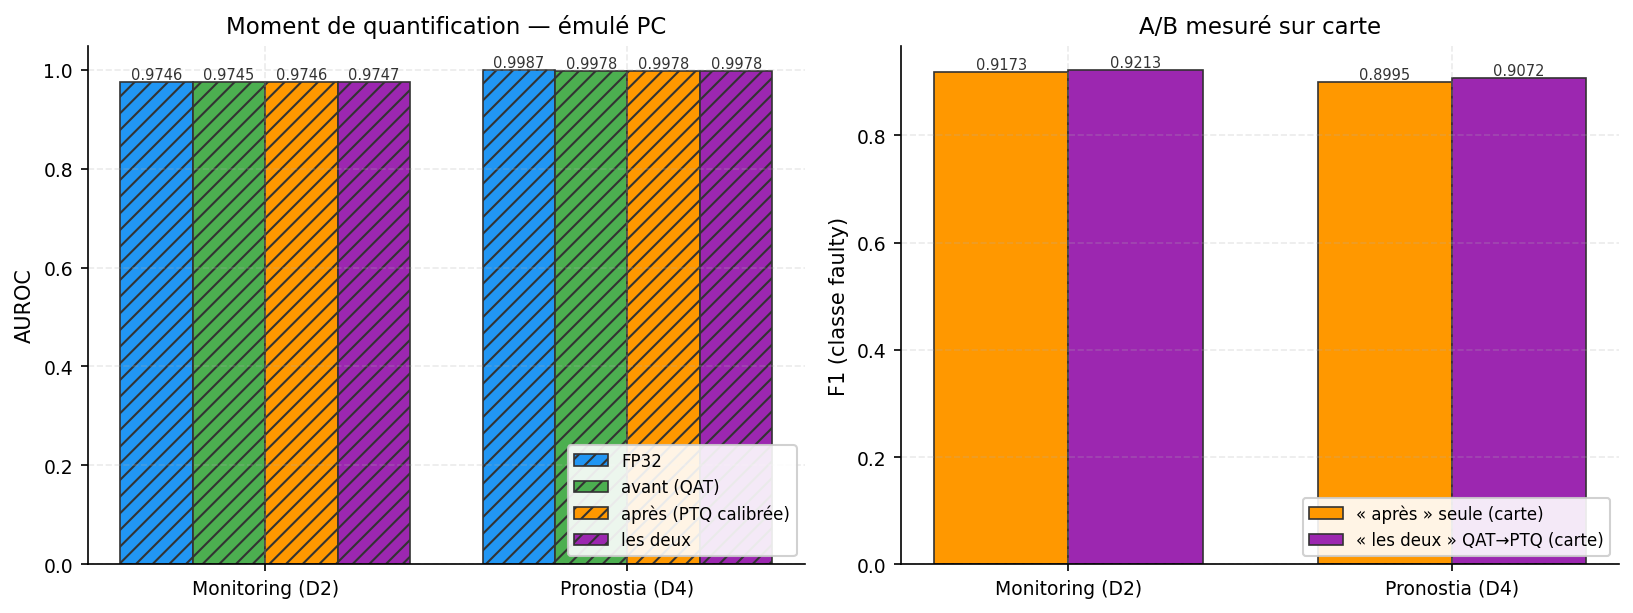

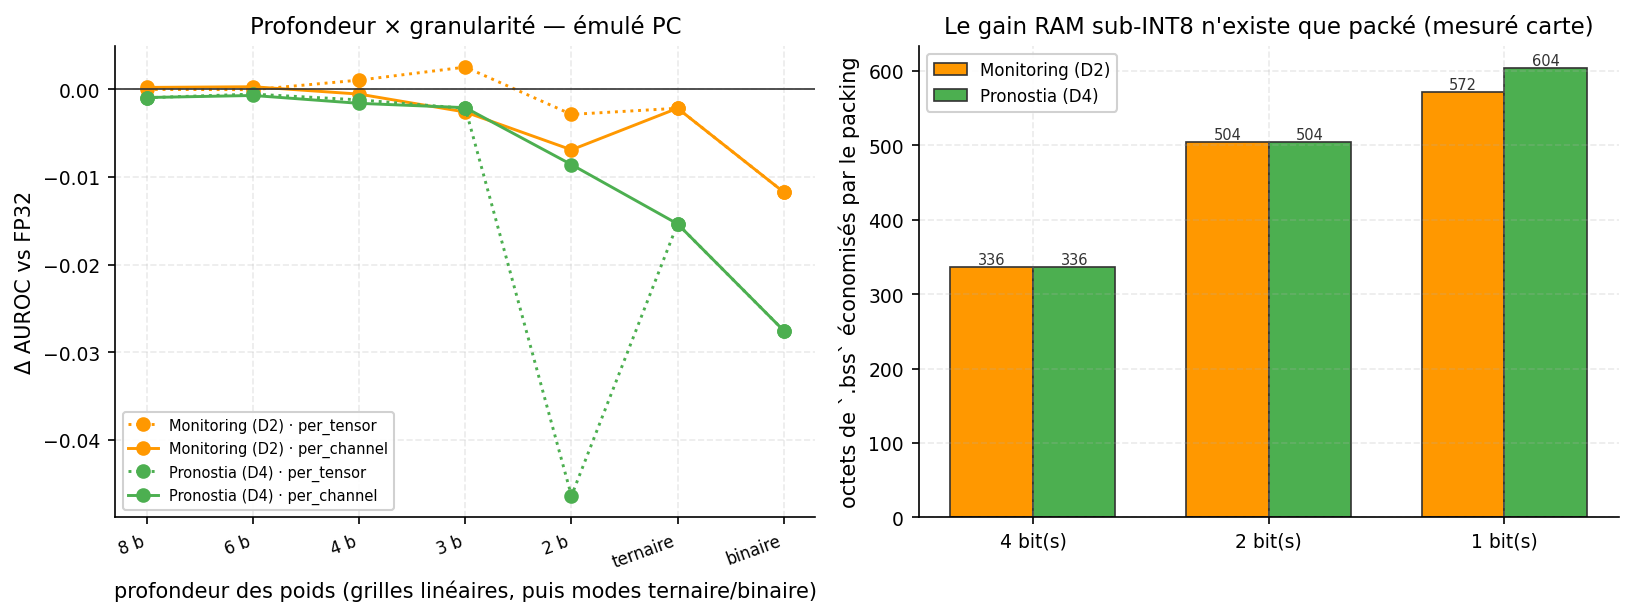

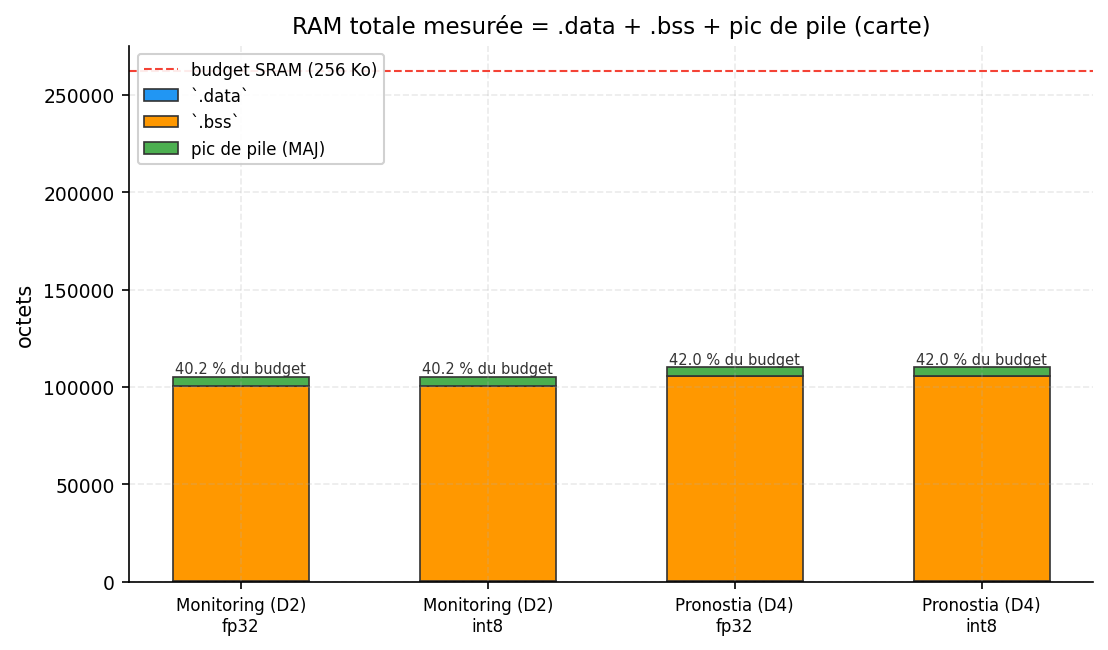

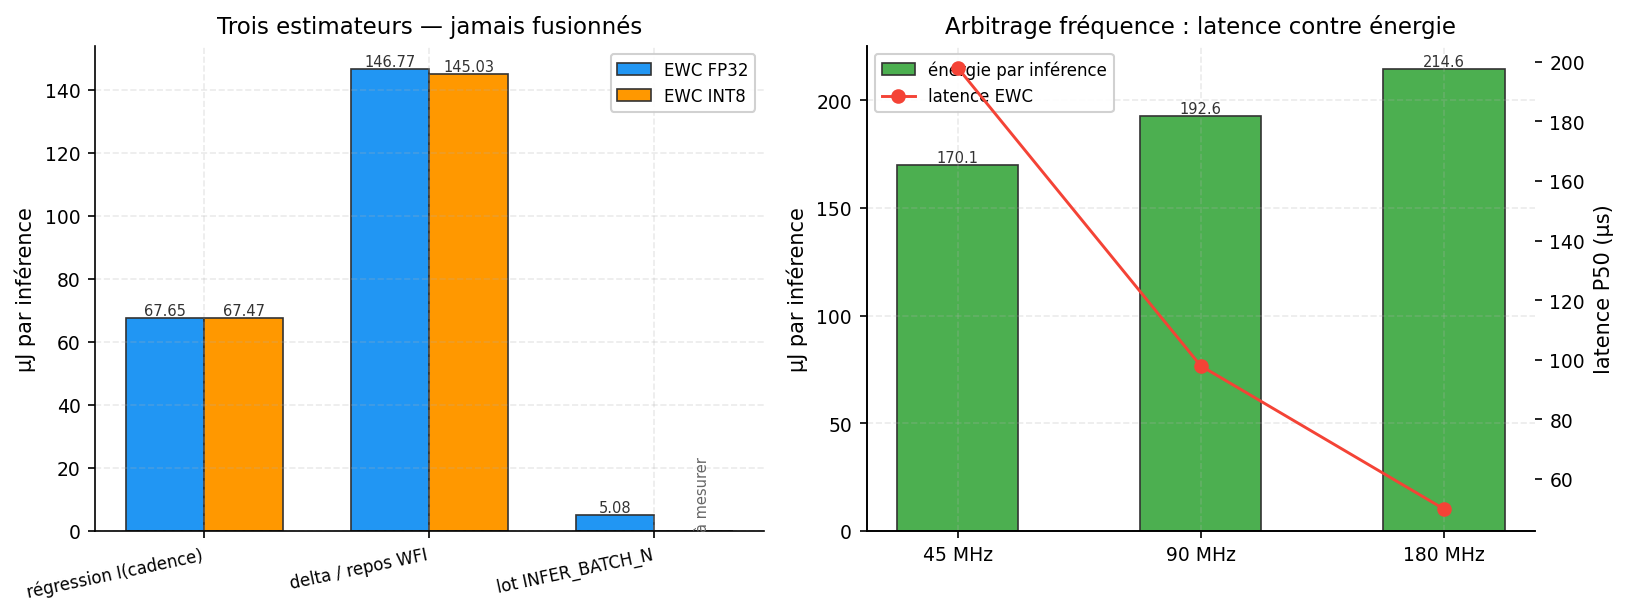

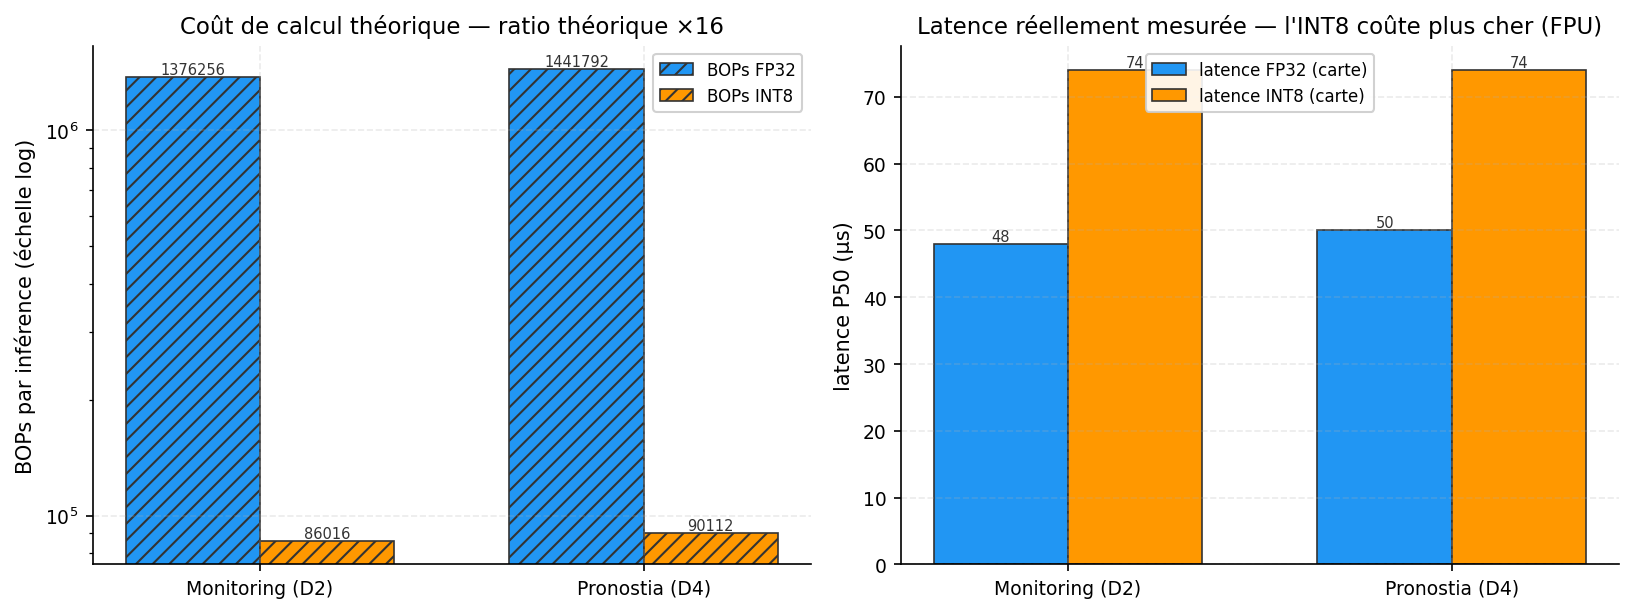

In [4]:
for name in [
    "fig6_quant_moment.png",
    "fig7_quant_depth_packing.png",
    "fig8_ram_total.png",
    "fig9_energy_estimators.png",
    "fig10_compute_cost.png",
]:
    display(Image(filename=str(FIGS / name)))

## 3. Table de provenance — source unique du `.tex`

Chaque grandeur citée dans l'article, sa valeur, son fichier d'origine et son statut. Elle est
construite **depuis l'agrégat** : une cellule mesurée ne peut donc plus rester marquée
`« à mesurer »`, défaut exact que la refonte corrige (`F1 per_ch board monitoring` portait ce statut
alors que le JSON existait).

In [5]:
def cell(*path):
    """Cellule {value, source_json, platform, na_reason} de l'agrégat."""
    node = SUMMARY
    for key in path:
        node = node[key]
    return node


ROWS = []


def note(label, *path):
    c = cell(*path)
    value = c["value"]
    measured = value is not None and value != NA
    ROWS.append({
        "grandeur": label,
        # Une valeur non mesurée reste VIDE dans la table (jamais 0, jamais un substitut).
        "valeur": value if measured else "",
        "source_json": c["source_json"].replace("experiments/", ""),
        "statut": c["platform"] if measured else NA,
    })


for ds in DATASETS:
    note(f"parité FP32 gelé {ds}", ds, "performance", "board_frozen_parity_rate")
    note(f"parité FP32 en ligne {ds}", ds, "performance", "board_online_parity_rate")
    note(f"F1 FP32 board {ds}", ds, "performance", "board_frozen_f1_faulty")
    note(f"F1 legacy board {ds}", ds, "performance", "board_frozen_int8_legacy_f1_faulty")
    note(f"F1 per_ch émulé {ds}", ds, "ablation_int8", "scheme_int8_perchannel_metric")
    note(f"F1 per_ch board {ds}", ds, "recovery_board", "per_channel_frozen_f1_faulty")
    note(f"F1 q15 board {ds}", ds, "recovery_board", "q15_frozen_f1_faulty")
    note(f"latence board FP32 {ds}", ds, "performance", "board_frozen_latency_us_p50")
    note(f"latence board INT8 {ds}", ds, "latency", "total_int8_us_p50")
    note(f"RAM totale board fp32 {ds}", ds, "ram", "fp32_board_total")
    note(f"RAM totale board int8 {ds}", ds, "ram", "int8_board_total")
    note(f"F1 board « les deux » {ds}", ds, "moment", "board_both_f1_faulty")
    note(f"MACs {ds}", ds, "compute_cost", "macs")
    note(f"BOPs FP32 {ds}", ds, "compute_cost", "bops_fp32")
    note(f"BOPs INT8 {ds}", ds, "compute_cost", "bops_int8")

# Énergie : un estimateur par ligne, jamais agrégés entre eux.
for est, key in [("régression I(cadence)", "regression"), ("delta/WFI", "delta_wfi"),
                 ("lot INFER_BATCH_N", "batch")]:
    note(f"énergie EWC FP32 — {est}", "energy", "estimators", key, "cells",
         "ewc_fp32_energy_uj_per_inference")
note("énergie par MAJ CL — delta/WFI", "energy", "estimators", "delta_wfi", "cells",
     "ewc_fp32_energy_uj_per_update")

import pandas as pd

df = pd.DataFrame(ROWS)
print("statuts :", df["statut"].value_counts().to_dict())
(FIGS / "provenance_table.csv").write_text(df.to_csv(index=False), encoding="utf-8")
df

statuts : {'mesuré board': 23, 'théorique': 6, 'à mesurer': 3, 'émulé PC': 2}


,grandeur,valeur,source_json,statut
0,parité FP32 gelé pronostia,1.0,exp_S36_summary.json,mesuré board
1,parité FP32 en ligne pronostia,0.975445,exp_S36_summary.json,mesuré board
2,F1 FP32 board pronostia,0.9164,exp_S36_summary.json,mesuré board
3,F1 legacy board pronostia,0.138,exp_S36_summary.json,mesuré board
4,F1 per_ch émulé pronostia,0.9437,exp_S39_quant_sweep/ewc_pronostia.json,émulé PC
5,F1 per_ch board pronostia,0.8995,exp_S40_board_v2/results_per_channel_pronostia...,mesuré board
6,F1 q15 board pronostia,,exp_S40_board_v2/results_q15_pronostia_frozen....,à mesurer
7,latence board FP32 pronostia,50.0,exp_S36_summary.json,mesuré board
8,latence board INT8 pronostia,74.0,exp_S50_int8_latency/ewc.json,mesuré board
9,RAM totale board fp32 pronostia,110192,exp_S49_ram/summary.json,mesuré board


## 4. Ce qui reste à mesurer

Ces cellules ne portent aucune valeur et ne doivent pas en recevoir tant que la campagne
correspondante n'a pas tourné. Le registre commenté vit dans
`docs/sprints/sprint_40/S4010_mesures_manquantes.md`.

In [6]:
for path in SUMMARY["missing"]:
    print(" ·", path)

 · energy.delta_wfi.cells.ewc_fp32_energy_uj_per_update
 · energy.delta_wfi.cells.ewc_int8_energy_uj_per_update
 · energy.policy_update.cells.monitoring_energy_uj_per_update
 · energy.policy_update.cells.pronostia_energy_uj_per_update
 · monitoring.ram.fp32_pc_bss
 · monitoring.ram.fp32_pc_data
 · monitoring.ram.fp32_pc_stack_peak_update
 · monitoring.ram.int8_pc_bss
 · monitoring.ram.int8_pc_data
 · monitoring.ram.int8_pc_stack_peak_inference
 · monitoring.ram.int8_pc_stack_peak_update
 · monitoring.ram.int8_pc_total
 · monitoring.recovery_board.int8_legacy_frozen_f1_faulty
 · monitoring.recovery_board.int8_legacy_online_f1_faulty
 · monitoring.recovery_board.q15_frozen_f1_faulty
 · monitoring.recovery_board.q15_online_f1_faulty
 · pronostia.ram.fp32_pc_bss
 · pronostia.ram.fp32_pc_data
 · pronostia.ram.fp32_pc_stack_peak_update
 · pronostia.ram.int8_pc_bss
 · pronostia.ram.int8_pc_data
 · pronostia.ram.int8_pc_stack_peak_inference
 · pronostia.ram.int8_pc_stack_peak_update
 · pronost